In [ ]:
# Goal: Image / Video auto-encoding, and test SoRL on them
# ----------------------------------------------------------



In [1]:
from dataclasses import dataclass
from itertools import cycle
from typing import Tuple

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


@dataclass
class VideoConfig:
    frames: int = 8
    size: int = 32
    dataset_len: int = 512
    batch_size: int = 32


def _make_grid(size: int) -> Tuple[torch.Tensor, torch.Tensor]:
    coords = torch.linspace(-1.0, 1.0, size)
    grid_y, grid_x = torch.meshgrid(coords, coords, indexing="ij")
    return grid_y, grid_x


class MovingBlobDataset(Dataset):
    def __init__(self, cfg: VideoConfig):
        self.cfg = cfg
        self.grid_y, self.grid_x = _make_grid(cfg.size)
        self.sigma = 0.12

    def __len__(self) -> int:
        return self.cfg.dataset_len

    def _draw_blob(self, center: torch.Tensor) -> torch.Tensor:
        dist2 = (self.grid_x - center[0]) ** 2 + (self.grid_y - center[1]) ** 2
        frame = torch.exp(-dist2 / (2 * self.sigma**2))
        return frame.unsqueeze(0)

    def __getitem__(self, idx: int) -> torch.Tensor:  # noqa: ARG002
        cfg = self.cfg
        base = torch.rand(2) * 1.4 - 0.7
        velocity = (torch.rand(2) - 0.5) * 0.6
        times = torch.linspace(-0.6, 0.6, cfg.frames).unsqueeze(1)
        centers = (base + times * velocity).clamp(-0.9, 0.9)
        video = torch.stack([self._draw_blob(c) for c in centers], dim=0)
        noise = torch.randn_like(video) * 0.02
        video = (video + noise).clamp(0.0, 1.0)
        return video.permute(1, 0, 2, 3)  # -> (C, T, H, W)


cfg = VideoConfig()
dataset = MovingBlobDataset(cfg)
dataloader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
train_stream = cycle(dataloader)

In [2]:
class TinyVideoAE(nn.Module):
    def __init__(self, latent_dim: int = 96):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, stride=(1, 2, 2), padding=1),
            nn.GELU(),
            nn.Conv3d(16, 32, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.GELU(),
            nn.Conv3d(32, 64, kernel_size=3, stride=(2, 2, 2), padding=1),
            nn.GELU(),
        )
        encoded_dim = 64 * 2 * 4 * 4
        self.enc_norm = nn.LayerNorm(encoded_dim)
        self.to_latent = nn.Linear(encoded_dim, latent_dim)
        self.from_latent = nn.Linear(latent_dim, encoded_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose3d(32, 16, kernel_size=4, stride=(2, 2, 2), padding=1),
            nn.GELU(),
            nn.ConvTranspose3d(16, 8, kernel_size=(3, 4, 4), stride=(1, 2, 2), padding=1),
            nn.GELU(),
            nn.Conv3d(8, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        h = self.encoder(x).flatten(1)
        return self.to_latent(self.enc_norm(h))

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        h = self.from_latent(z).view(-1, 64, 2, 4, 4)
        return self.decoder(h)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decode(self.encode(x))


def count_parameters(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


model = TinyVideoAE().to(device)
print(f"TinyVideoAE params: {count_parameters(model)/1e6:.2f} M")



TinyVideoAE params: 0.64 M


step 0050/400 | loss=0.0054
step 0100/400 | loss=0.0054
step 0150/400 | loss=0.0054
step 0200/400 | loss=0.0054
step 0250/400 | loss=0.0054
step 0300/400 | loss=0.0054
step 0350/400 | loss=0.0054
step 0400/400 | loss=0.0054


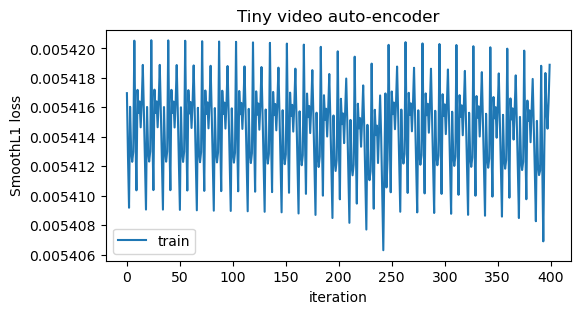

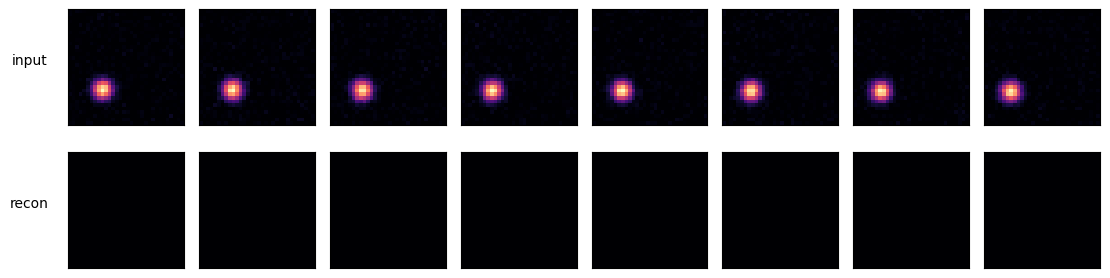

In [16]:
train_steps = 400
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
history = []

model.train()
for step in range(1, train_steps + 1):
    batch = next(train_stream).to(device)
    recon = model(batch)
    loss = criterion(recon, batch)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    history.append(loss.item())
    if step % 50 == 0:
        print(f"step {step:04d}/{train_steps} | loss={loss.item():.4f}")

plt.figure(figsize=(6, 3))
plt.plot(history, label="train")
plt.xlabel("iteration")
plt.ylabel("SmoothL1 loss")
plt.title("Tiny video auto-encoder")
plt.legend()
plt.show()


def visualize_reconstruction(example_idx: int = 0) -> None:
    model.eval()
    with torch.no_grad():
        original = dataset[example_idx].unsqueeze(0).to(device)
        recon = model(original).cpu()
    original = original.cpu()

    fig, axes = plt.subplots(2, cfg.frames, figsize=(cfg.frames * 1.4, 3.2))
    for row, tensor, label in zip(axes, (original, recon), ("input", "recon")):
        for col, ax in enumerate(row):
            ax.imshow(tensor[0, 0, col], cmap="magma", vmin=0, vmax=1)
            if col == 0:
                ax.set_ylabel(label, rotation=0, labelpad=28, fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.show()


visualize_reconstruction(example_idx=3)

